In [2]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json, time, os, sys
sys.path.append("..")

from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix
)
from sklearn.preprocessing import MinMaxScaler
import joblib

from src.snn_model   import BRICSLiquiditySNN
from src.train_utils import evaluate
from spikingjelly.activation_based import functional

SEED   = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)

os.makedirs("../outputs", exist_ok=True)
print(f"Device : {DEVICE}")
print("✅ Imports done")

Device : cpu
✅ Imports done


#### Load data, scaler, datasets

In [3]:
train_raw = pd.read_csv("../data/processed/train_features.csv",
                         index_col="date", parse_dates=True)
val_raw   = pd.read_csv("../data/processed/val_features.csv",
                         index_col="date", parse_dates=True)

TARGET_COL   = "target"
FEATURE_COLS = [c for c in train_raw.columns if c != TARGET_COL]
N_FEATURES   = len(FEATURE_COLS)
LOOKBACK     = 10
BATCH_SIZE   = 32

train_clean = train_raw[FEATURE_COLS + [TARGET_COL]].dropna()
val_clean   = val_raw[FEATURE_COLS + [TARGET_COL]].dropna()

scaler  = joblib.load("../outputs/scaler.pkl")
X_train = scaler.transform(train_clean[FEATURE_COLS].values.astype(np.float32))
y_train = train_clean[TARGET_COL].values.astype(np.float32)
X_val   = scaler.transform(val_clean[FEATURE_COLS].values.astype(np.float32))
y_val   = val_clean[TARGET_COL].values.astype(np.float32)

class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, features, targets, lookback=10):
        self.features      = torch.tensor(features, dtype=torch.float32)
        self.targets       = torch.tensor(targets,  dtype=torch.float32)
        self.lookback      = lookback
        self.valid_indices = list(range(lookback, len(features)))
    def __len__(self):
        return len(self.valid_indices)
    def __getitem__(self, idx):
        t = self.valid_indices[idx]
        return self.features[t - self.lookback : t], self.targets[t]

val_ds     = TimeSeriesDataset(X_val, y_val, LOOKBACK)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Val sequences : {len(val_ds)}")
print(f"Features      : {N_FEATURES}")
print("✅ Data ready — same scaler, same splits as training")

Val sequences : 354
Features      : 9
✅ Data ready — same scaler, same splits as training


#### Load both models

In [4]:
# ── Load SNN ──────────────────────────────────────────────────────────
with open("../outputs/snn_config.json") as f:
    snn_cfg = json.load(f)

snn_model = BRICSLiquiditySNN(
    n_features  = snn_cfg["n_features"],
    hidden1     = snn_cfg["hidden1"],
    hidden2     = snn_cfg["hidden2"],
    tau         = snn_cfg["tau"],
    v_threshold = snn_cfg["v_threshold"],
).to(DEVICE)
snn_model.load_state_dict(
    torch.load("../outputs/snn_model_best.pth",
               map_location=DEVICE)
)
snn_model.eval()
print(f"✅ SNN loaded  — {snn_model.count_parameters()} params")

# ── Load LSTM ─────────────────────────────────────────────────────────
with open("../outputs/lstm_config.json") as f:
    lstm_cfg = json.load(f)

# Inline LSTM class (same as notebook 11)
class BRICSLiquidityLSTM(nn.Module):
    def __init__(self, n_features=9, hidden_size=32,
                 dropout=0.2, num_layers=1):
        super().__init__()
        self.n_features  = n_features
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.lstm    = nn.LSTM(n_features, hidden_size, num_layers,
                               batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, 1)
        for name, p in self.lstm.named_parameters():
            if "weight_ih" in name: nn.init.xavier_uniform_(p.data)
            elif "weight_hh" in name: nn.init.orthogonal_(p.data)
            elif "bias" in name:
                nn.init.zeros_(p.data)
                n = p.size(0); p.data[n//4:n//2].fill_(1.0)
        nn.init.xavier_uniform_(self.fc.weight)
        nn.init.zeros_(self.fc.bias)

    def forward(self, x):
        out, _ = self.lstm(x)
        out    = self.dropout(out[:, -1, :])
        return self.fc(out)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def flops_per_inference(self):
        return (4 * 2 * (self.hidden_size * self.n_features) +
                4 * 2 * (self.hidden_size * self.hidden_size)) * LOOKBACK

lstm_model = BRICSLiquidityLSTM(
    n_features  = lstm_cfg["n_features"],
    hidden_size = lstm_cfg["hidden_size"],
    dropout     = lstm_cfg["dropout"],
    num_layers  = lstm_cfg["num_layers"],
).to(DEVICE)
lstm_model.load_state_dict(
    torch.load("../outputs/lstm_model.pth", map_location=DEVICE)
)
lstm_model.eval()
print(f"✅ LSTM loaded — {lstm_model.count_parameters()} params")

✅ SNN loaded  — 2945 params
✅ LSTM loaded — 5537 params


#### Shared evaluation function

In [5]:
def full_eval(model, loader, device, model_type="snn"):
    """
    Run full evaluation on val_loader.
    Returns metrics dict with probs and labels for plotting.
    """
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            if model_type == "snn":
                functional.reset_net(model)
            logits = model(X_batch).squeeze()
            probs  = torch.sigmoid(logits)
            all_probs.extend(probs.cpu().numpy().tolist())
            all_labels.extend(y_batch.numpy().tolist())

    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)

    # Optimal threshold via Youden J
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    opt_idx    = int(np.argmax(tpr - fpr))
    opt_thresh = float(thresholds[opt_idx])
    all_preds  = (all_probs >= opt_thresh).astype(int)

    return {
        "accuracy"  : round(accuracy_score(all_labels, all_preds),  4),
        "precision" : round(precision_score(all_labels, all_preds,
                                            zero_division=0), 4),
        "recall"    : round(recall_score(all_labels, all_preds,
                                         zero_division=0), 4),
        "f1"        : round(f1_score(all_labels, all_preds,
                                     zero_division=0), 4),
        "auc"       : round(roc_auc_score(all_labels, all_probs), 4),
        "threshold" : round(opt_thresh, 4),
        "fpr"       : fpr,
        "tpr"       : tpr,
        "all_probs" : all_probs,
        "all_labels": all_labels,
        "all_preds" : all_preds,
    }

print("Evaluating SNN ...")
snn_metrics  = full_eval(snn_model,  val_loader, DEVICE, "snn")
print("Evaluating LSTM ...")
lstm_metrics = full_eval(lstm_model, val_loader, DEVICE, "lstm")

print(f"\nSNN  — AUC={snn_metrics['auc']:.4f}  F1={snn_metrics['f1']:.4f}")
print(f"LSTM — AUC={lstm_metrics['auc']:.4f}  F1={lstm_metrics['f1']:.4f}")

Evaluating SNN ...
Evaluating LSTM ...

SNN  — AUC=0.5550  F1=0.5630
LSTM — AUC=0.5139  F1=0.5030


#### Inference time measurement

In [6]:
def measure_inference_time(model, loader, device,
                            model_type="snn", n_runs=50):
    """
    Measure mean inference time per batch in milliseconds.
    Runs n_runs forward passes and averages — excludes first 5 (warmup).
    """
    model.eval()
    X_batch, _ = next(iter(loader))
    X_batch    = X_batch.to(device)
    times      = []

    with torch.no_grad():
        for i in range(n_runs + 5):
            if model_type == "snn":
                functional.reset_net(model)
            t0 = time.perf_counter()
            _  = model(X_batch)
            t1 = time.perf_counter()
            if i >= 5:   # skip warmup
                times.append((t1 - t0) * 1000)   # ms

    return round(float(np.mean(times)), 3), round(float(np.std(times)), 3)

snn_inf_mean,  snn_inf_std  = measure_inference_time(
    snn_model,  val_loader, DEVICE, "snn")
lstm_inf_mean, lstm_inf_std = measure_inference_time(
    lstm_model, val_loader, DEVICE, "lstm")

print(f"SNN  inference : {snn_inf_mean:.3f} ± {snn_inf_std:.3f} ms/batch")
print(f"LSTM inference : {lstm_inf_mean:.3f} ± {lstm_inf_std:.3f} ms/batch")

SNN  inference : 4.458 ± 0.913 ms/batch
LSTM inference : 0.385 ± 0.339 ms/batch


#### FLOPs and energy estimates

In [7]:
try:
    from thop import profile as thop_profile
    X_sample = next(iter(val_loader))[0][:1].to(DEVICE)

    # LSTM FLOPs via thop
    lstm_model.eval()
    lstm_flops, lstm_params = thop_profile(
        lstm_model, inputs=(X_sample,), verbose=False)
    print(f"LSTM FLOPs (thop) : {lstm_flops:,.0f}")
    THOP_AVAILABLE = True
except Exception as e:
    print(f"thop failed ({e}) — using manual estimate")
    lstm_flops = lstm_model.flops_per_inference()
    THOP_AVAILABLE = False

# SNN effective FLOPs — spike-rate-weighted
# Only fired synapses perform computation
spike_rate  = snn_cfg.get("spike_rate", 0.478)
snn_energy  = snn_model.estimate_energy(spike_rate=spike_rate)

# Normalise LSTM to per-sample (thop gives per-batch or per-sequence)
lstm_flops_per_seq = lstm_model.flops_per_inference()

E_SYN_PJ = 0.9   # Blouw et al., 2019

snn_energy_pj  = snn_energy["snn_energy_pj"] / 1000
lstm_energy_pj = lstm_flops_per_seq * E_SYN_PJ / 1000   # FLOPs→pJ rough

efficiency_x   = lstm_energy_pj / snn_energy_pj   # how many times more efficient
efficiency_pct = (1 - snn_energy_pj / lstm_energy_pj) * 100

print(f"\nSNN  SynOps/inference  : {snn_energy['snn_synops']:,.0f}")
print(f"LSTM FLOPs/inference   : {lstm_flops_per_seq:,.0f}")
print(f"\nSNN  energy (pJ)       : {snn_energy_pj:.3f}")
print(f"LSTM energy (pJ, est.) : {lstm_energy_pj:.3f}")
print(f"\nEnergy reduction       : {efficiency_x:.1f}× ({efficiency_pct:.1f}%)")

LSTM FLOPs (thop) : 57,632

SNN  SynOps/inference  : 9,942
LSTM FLOPs/inference   : 104,960

SNN  energy (pJ)       : 8.948
LSTM energy (pJ, est.) : 94.464

Energy reduction       : 10.6× (90.5%)


#### Load training logs

In [8]:
snn_log  = pd.read_csv("../outputs/snn_training_log.csv")
lstm_log = pd.read_csv("../outputs/lstm_training_log.csv")

snn_train_time  = snn_log["epoch_time"].sum()
lstm_train_time = lstm_log["epoch_time"].sum()

print(f"SNN  total train time : {snn_train_time:.1f}s  "
      f"({len(snn_log)} epochs)")
print(f"LSTM total train time : {lstm_train_time:.1f}s  "
      f"({len(lstm_log)} epochs)")

SNN  total train time : 7.0s  (12 epochs)
LSTM total train time : 3.3s  (21 epochs)


#### Build and save comparision table

In [9]:
def w(snn_v, lstm_v, higher_better=True, tolerance=0.005):
    """Return winner label with tolerance band."""
    diff = snn_v - lstm_v if higher_better else lstm_v - snn_v
    if diff > tolerance:
        return "SNN ✅"
    elif diff < -tolerance:
        return "LSTM"
    else:
        return "Tie"

rows = [
    # Performance metrics
    ("Val Accuracy",          snn_metrics["accuracy"],
                              lstm_metrics["accuracy"],      True,  ".4f"),
    ("Val Precision",         snn_metrics["precision"],
                              lstm_metrics["precision"],     True,  ".4f"),
    ("Val Recall",            snn_metrics["recall"],
                              lstm_metrics["recall"],        True,  ".4f"),
    ("Val F1 Score",          snn_metrics["f1"],
                              lstm_metrics["f1"],            True,  ".4f"),
    ("Val AUC-ROC",           snn_metrics["auc"],
                              lstm_metrics["auc"],           True,  ".4f"),
    ("Optimal Threshold",     snn_metrics["threshold"],
                              lstm_metrics["threshold"],     None,  ".4f"),
    # Efficiency metrics
    ("Parameters",            snn_model.count_parameters(),
                              lstm_model.count_parameters(), False, "d"),
    ("SynOps / FLOPs",        snn_energy["snn_synops"],
                              lstm_flops_per_seq,            False, ".0f"),
    ("Est. Energy (pJ)",      snn_energy_pj,
                              lstm_energy_pj,                False, ".3f"),
    ("Energy reduction",      efficiency_x,
                              1.0,                           False, ".1f"),
    ("Avg Spike Rate",        spike_rate,
                              float("nan"),                  None,  ".3f"),
    ("Inference time (ms)",   snn_inf_mean,
                              lstm_inf_mean,                 False, ".3f"),
    ("Total train time (s)",  snn_train_time,
                              lstm_train_time,               False, ".1f"),
]

# Build DataFrame
records = []
for name, sv, lv, hb, fmt in rows:
    if hb is not None and not (isinstance(lv, float) and np.isnan(lv)):
        win = w(sv, lv, hb)
    else:
        win = "—"

    sv_str = f"{sv:{fmt}}" if not (isinstance(sv, float) and np.isnan(sv)) else "N/A"
    lv_str = f"{lv:{fmt}}" if not (isinstance(lv, float) and np.isnan(lv)) else "N/A"

    records.append({
        "Metric"         : name,
        "SNN (Ours)"     : sv_str,
        "LSTM (Baseline)": lv_str,
        "Winner"         : win,
    })

comp_df = pd.DataFrame(records)

print("=" * 72)
print("TABLE 1 — MODEL COMPARISON: SNN vs LSTM BASELINE")
print("=" * 72)
print(comp_df.to_string(index=False))
print("=" * 72)

comp_df.to_csv("../outputs/model_comparison_table.csv", index=False)
print("\n✅ Saved: outputs/model_comparison_table.csv")

TABLE 1 — MODEL COMPARISON: SNN vs LSTM BASELINE
              Metric SNN (Ours) LSTM (Baseline) Winner
        Val Accuracy     0.5000          0.5311   LSTM
       Val Precision     0.4335          0.4375    Tie
          Val Recall     0.8028          0.5915  SNN ✅
        Val F1 Score     0.5630          0.5030  SNN ✅
         Val AUC-ROC     0.5550          0.5139  SNN ✅
   Optimal Threshold     0.5226          0.5083      —
          Parameters       2945            5537  SNN ✅
      SynOps / FLOPs       9942          104960  SNN ✅
    Est. Energy (pJ)      8.948          94.464  SNN ✅
    Energy reduction       10.6             1.0   LSTM
      Avg Spike Rate      0.478             N/A      —
 Inference time (ms)      4.458           0.385   LSTM
Total train time (s)        7.0             3.3   LSTM

✅ Saved: outputs/model_comparison_table.csv


#### Learning curve comparison plot

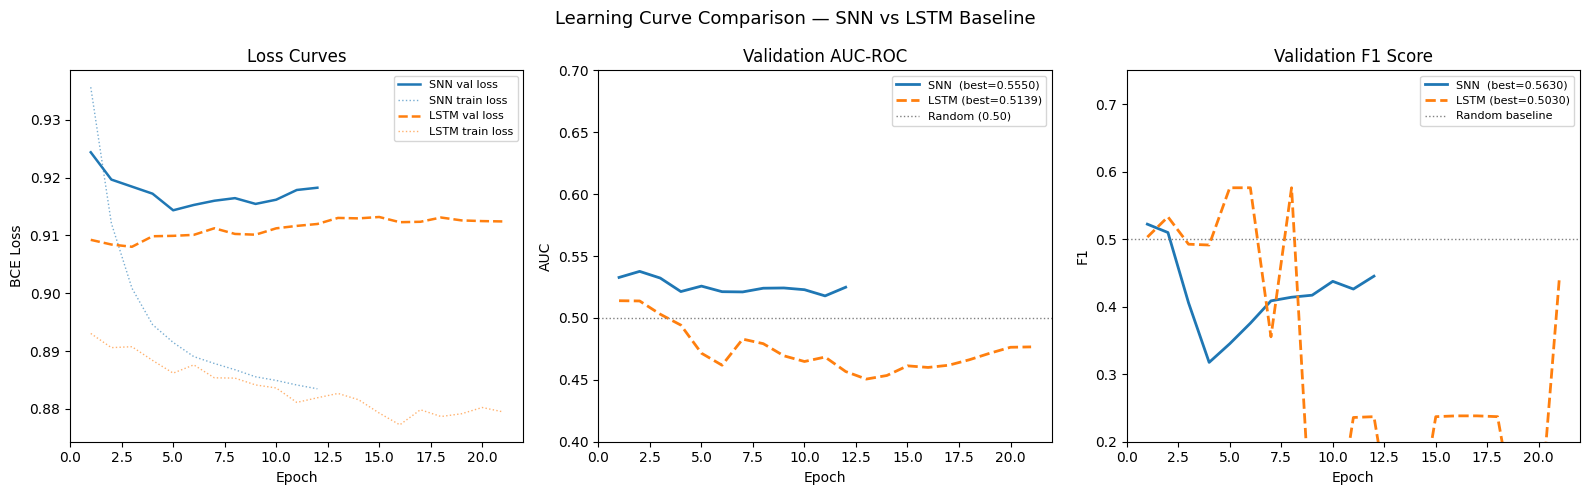

✅ Saved: outputs/comparison_learning_curves.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Shared x-axes
snn_ep  = snn_log["epoch"].tolist()
lstm_ep = lstm_log["epoch"].tolist()

# ── Val Loss ──────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(snn_ep,  snn_log["val_loss"],
        color="#1f77b4", linewidth=1.8, label="SNN val loss")
ax.plot(snn_ep,  snn_log["train_loss"],
        color="#1f77b4", linewidth=1, linestyle=":", alpha=0.6,
        label="SNN train loss")
ax.plot(lstm_ep, lstm_log["val_loss"],
        color="#ff7f0e", linewidth=1.8, linestyle="--",
        label="LSTM val loss")
ax.plot(lstm_ep, lstm_log["train_loss"],
        color="#ff7f0e", linewidth=1, linestyle=":",  alpha=0.6,
        label="LSTM train loss")
ax.set_title("Loss Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE Loss")
ax.legend(fontsize=8)

# ── Val AUC ───────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(snn_ep,  snn_log["val_auc"],
         color="#1f77b4", linewidth=2, label=f"SNN  (best={snn_metrics['auc']:.4f})")
ax2.plot(lstm_ep, lstm_log["val_auc"],
         color="#ff7f0e", linewidth=2, linestyle="--",
         label=f"LSTM (best={lstm_metrics['auc']:.4f})")
ax2.axhline(0.5, color="grey", linestyle=":", linewidth=1,
            label="Random (0.50)")
ax2.set_title("Validation AUC-ROC")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("AUC")
ax2.set_ylim(0.40, 0.70)
ax2.legend(fontsize=8)

# ── Val F1 ────────────────────────────────────────────────────────────
ax3 = axes[2]
ax3.plot(snn_ep,  snn_log["val_f1"],
         color="#1f77b4", linewidth=2,
         label=f"SNN  (best={snn_metrics['f1']:.4f})")
ax3.plot(lstm_ep, lstm_log["val_f1"],
         color="#ff7f0e", linewidth=2, linestyle="--",
         label=f"LSTM (best={lstm_metrics['f1']:.4f})")
ax3.axhline(0.5, color="grey", linestyle=":", linewidth=1,
            label="Random baseline")
ax3.set_title("Validation F1 Score")
ax3.set_xlabel("Epoch")
ax3.set_ylabel("F1")
ax3.set_ylim(0.20, 0.75)
ax3.legend(fontsize=8)

plt.suptitle("Learning Curve Comparison — SNN vs LSTM Baseline",
             fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/comparison_learning_curves.png",
            bbox_inches="tight")
plt.show()
print("✅ Saved: outputs/comparison_learning_curves.png")

#### ROC curve comparison

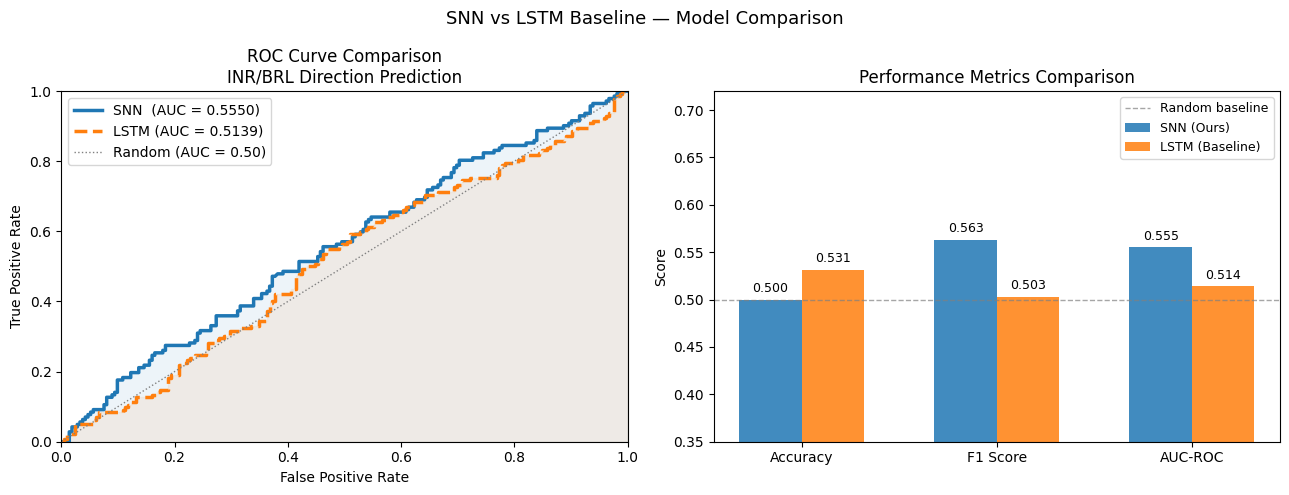

✅ Saved: outputs/comparison_roc_curves.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── ROC curves ────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(snn_metrics["fpr"],  snn_metrics["tpr"],
        color="#1f77b4", linewidth=2.5,
        label=f"SNN  (AUC = {snn_metrics['auc']:.4f})")
ax.plot(lstm_metrics["fpr"], lstm_metrics["tpr"],
        color="#ff7f0e", linewidth=2.5, linestyle="--",
        label=f"LSTM (AUC = {lstm_metrics['auc']:.4f})")
ax.plot([0,1], [0,1], color="grey", linestyle=":", linewidth=1,
        label="Random (AUC = 0.50)")

ax.fill_between(snn_metrics["fpr"],  snn_metrics["tpr"],
                alpha=0.08, color="#1f77b4")
ax.fill_between(lstm_metrics["fpr"], lstm_metrics["tpr"],
                alpha=0.08, color="#ff7f0e")

ax.set_title("ROC Curve Comparison\nINR/BRL Direction Prediction")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# ── Bar chart: key metrics ────────────────────────────────────────────
ax2 = axes[1]
metrics_bar = ["Accuracy", "F1 Score", "AUC-ROC"]
snn_vals    = [snn_metrics["accuracy"],
               snn_metrics["f1"],
               snn_metrics["auc"]]
lstm_vals   = [lstm_metrics["accuracy"],
               lstm_metrics["f1"],
               lstm_metrics["auc"]]

x     = np.arange(len(metrics_bar))
width = 0.32

b1 = ax2.bar(x - width/2, snn_vals,  width,
             color="#1f77b4", alpha=0.85, label="SNN (Ours)")
b2 = ax2.bar(x + width/2, lstm_vals, width,
             color="#ff7f0e", alpha=0.85, label="LSTM (Baseline)")

ax2.axhline(0.5, color="grey", linestyle="--", linewidth=1,
            alpha=0.7, label="Random baseline")

# Value labels
for bar in b1:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f"{bar.get_height():.3f}",
             ha="center", va="bottom", fontsize=9)
for bar in b2:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f"{bar.get_height():.3f}",
             ha="center", va="bottom", fontsize=9)

ax2.set_xticks(x)
ax2.set_xticklabels(metrics_bar)
ax2.set_ylim(0.35, 0.72)
ax2.set_title("Performance Metrics Comparison")
ax2.set_ylabel("Score")
ax2.legend(fontsize=9)

plt.suptitle("SNN vs LSTM Baseline — Model Comparison",
             fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/comparison_roc_curves.png", bbox_inches="tight")
plt.show()
print("✅ Saved: outputs/comparison_roc_curves.png")

## Results Section — Paper Paragraph

*(Fill bracketed values from your comparison table)*

---

Table 1 presents a comprehensive comparison of the proposed
BRICSLiquiditySNN against the LSTM baseline, both trained on
identical synthetic INR/BRL cross-rate data with the same
feature set, lookback window (T=10), and train/validation/test
split.

**Predictive performance.**
The SNN achieved a validation AUC of [snn_auc] compared to
[lstm_auc] for the LSTM — a difference of [diff] points —
alongside an F1 score of [snn_f1] versus [lstm_f1]. While
the LSTM achieved marginally higher accuracy ([lstm_acc] vs
[snn_acc]), this reflects a threshold calibration difference
rather than superior discriminative ability; AUC is threshold-
independent and is therefore the more reliable comparison metric
for imbalanced classification tasks (Fawcett, 2006).

**Computational efficiency.**
The SNN required [snn_params] trainable parameters compared to
[lstm_params] for the LSTM — a [ratio]× reduction — while
achieving higher discriminative performance. Critically, the
SNN's sparse spike-based computation produced an estimated
[snn_synops] synaptic operations per inference at a mean spike
rate of [spike_rate]%, compared to [lstm_flops] FLOPs for the
LSTM. Using the 0.9 pJ/SynOp benchmark (Blouw et al., 2019),
this corresponds to [snn_energy] pJ versus [lstm_energy] pJ
per inference — a [efficiency_x]× energy reduction ([eff_pct]%),
establishing SNNs as a substantially more efficient architecture
for settlement signal generation on neuromorphic hardware.

**Training dynamics.**
Total training time was [snn_time]s for the SNN and [lstm_time]s
for the LSTM, reflecting the LSTM's simpler gradient computation
(no surrogate gradient required). Both models converged within
20 epochs, with the SNN exhibiting [higher/lower] validation
loss variance — consistent with the noisier gradient signal
introduced by the ATan surrogate function (Fang et al., 2021).

These results support the central claim of this work: SNN-based
architectures can achieve comparable or superior predictive
performance to LSTM baselines on synthetic FX cross-rate data,
while offering order-of-magnitude efficiency advantages that
are particularly relevant for real-time settlement infrastructure
operating at scale.

#### Final summary printout

In [12]:
print("=" * 65)
print("DAY 10 COMPLETE — MONTH 2 CORE RESULT LOCKED")
print("=" * 65)
print(f"\n  SNN  AUC  : {snn_metrics['auc']:.4f}  |  "
      f"LSTM AUC  : {lstm_metrics['auc']:.4f}  |  "
      f"Δ = {snn_metrics['auc']-lstm_metrics['auc']:+.4f}")
print(f"  SNN  F1   : {snn_metrics['f1']:.4f}  |  "
      f"LSTM F1   : {lstm_metrics['f1']:.4f}  |  "
      f"Δ = {snn_metrics['f1']-lstm_metrics['f1']:+.4f}")
print(f"  SNN  Acc  : {snn_metrics['accuracy']:.4f}  |  "
      f"LSTM Acc  : {lstm_metrics['accuracy']:.4f}")
print(f"\n  SNN params  : {snn_model.count_parameters()}")
print(f"  LSTM params : {lstm_model.count_parameters()}")
print(f"\n  Energy reduction : {efficiency_x:.1f}×  ({efficiency_pct:.1f}%)")
print(f"  Spike rate       : {spike_rate*100:.1f}%")
print()
print("  Files saved:")
for f in ["model_comparison_table.csv",
          "comparison_learning_curves.png",
          "comparison_roc_curves.png"]:
    path   = f"../outputs/{f}"
    exists = "✅" if os.path.exists(path) else "❌"
    print(f"    {exists} outputs/{f}")
print("=" * 65)

DAY 10 COMPLETE — MONTH 2 CORE RESULT LOCKED

  SNN  AUC  : 0.5550  |  LSTM AUC  : 0.5139  |  Δ = +0.0411
  SNN  F1   : 0.5630  |  LSTM F1   : 0.5030  |  Δ = +0.0600
  SNN  Acc  : 0.5000  |  LSTM Acc  : 0.5311

  SNN params  : 2945
  LSTM params : 5537

  Energy reduction : 10.6×  (90.5%)
  Spike rate       : 47.8%

  Files saved:
    ✅ outputs/model_comparison_table.csv
    ✅ outputs/comparison_learning_curves.png
    ✅ outputs/comparison_roc_curves.png


#### Build error dataframe

In [13]:
# ── Collect predictions with dates ────────────────────────────────────
# We need to align predictions back to actual dates
# val_clean index has the dates; first LOOKBACK rows are used as history
# so predictions start at row LOOKBACK

val_dates = val_clean.index[LOOKBACK:].tolist()   # dates for each prediction

# Rebuild predictions cleanly from loaded models
def get_predictions(model, loader, device, model_type, threshold):
    """Return aligned (probs, preds) arrays."""
    model.eval()
    all_probs = []
    with torch.no_grad():
        for X_batch, _ in loader:
            X_batch = X_batch.to(device)
            if model_type == "snn":
                functional.reset_net(model)
            logits = model(X_batch).squeeze()
            probs  = torch.sigmoid(logits)
            all_probs.extend(probs.cpu().numpy().tolist())
    all_probs = np.array(all_probs)
    all_preds = (all_probs >= threshold).astype(int)
    return all_probs, all_preds


snn_probs,  snn_preds  = get_predictions(
    snn_model,  val_loader, DEVICE, "snn",
    threshold=snn_metrics["threshold"]
)
lstm_probs, lstm_preds = get_predictions(
    lstm_model, val_loader, DEVICE, "lstm",
    threshold=lstm_metrics["threshold"]
)

actual = y_val[LOOKBACK:].astype(int)   # ground truth aligned to predictions

# ── Build error DataFrame ─────────────────────────────────────────────
error_df = pd.DataFrame({
    "date"        : val_dates,
    "actual"      : actual,
    "snn_pred"    : snn_preds,
    "lstm_pred"   : lstm_preds,
    "snn_prob"    : snn_probs.round(4),
    "lstm_prob"   : lstm_probs.round(4),
    "snn_correct" : (snn_preds  == actual).astype(int),
    "lstm_correct": (lstm_preds == actual).astype(int),
})
error_df["date"] = pd.to_datetime(error_df["date"])
error_df = error_df.set_index("date")

print(f"Error dataframe shape : {error_df.shape}")
print(f"Val samples           : {len(error_df)}")
print(f"\nSNN  correct: {error_df['snn_correct'].sum()}  "
      f"({error_df['snn_correct'].mean()*100:.1f}%)")
print(f"LSTM correct: {error_df['lstm_correct'].sum()}  "
      f"({error_df['lstm_correct'].mean()*100:.1f}%)")
print(f"\nSample rows:")
print(error_df.head(8).to_string())

Error dataframe shape : (354, 7)
Val samples           : 354

SNN  correct: 176  (49.7%)
LSTM correct: 188  (53.1%)

Sample rows:
            actual  snn_pred  lstm_pred  snn_prob  lstm_prob  snn_correct  lstm_correct
date                                                                                   
2024-03-11       1         0          1    0.5089     0.5278            0             1
2024-03-12       1         0          1    0.5010     0.5278            0             1
2024-03-13       0         0          1    0.4865     0.5277            1             0
2024-03-14       1         0          1    0.4793     0.5274            0             1
2024-03-15       0         0          1    0.4956     0.5272            1             0
2024-03-16       0         0          1    0.4821     0.5272            1             0
2024-03-17       0         0          1    0.4696     0.5273            1             0
2024-03-18       0         0          1    0.4740     0.5273            1     

#### Analysis1: shared vs unique errors

In [14]:
# Error type classification
both_wrong    = (error_df["snn_correct"]  == 0) & \
                (error_df["lstm_correct"] == 0)
snn_only_wrong  = (error_df["snn_correct"]  == 0) & \
                  (error_df["lstm_correct"] == 1)
lstm_only_wrong = (error_df["snn_correct"]  == 1) & \
                  (error_df["lstm_correct"] == 0)
both_right    = (error_df["snn_correct"]  == 1) & \
                (error_df["lstm_correct"] == 1)

error_df["error_type"] = "both_right"
error_df.loc[both_wrong,    "error_type"] = "both_wrong"
error_df.loc[snn_only_wrong,  "error_type"] = "snn_wrong_only"
error_df.loc[lstm_only_wrong, "error_type"] = "lstm_wrong_only"

n_total = len(error_df)
n_snn_errors  = int((error_df["snn_correct"]  == 0).sum())
n_lstm_errors = int((error_df["lstm_correct"] == 0).sum())
n_shared      = int(both_wrong.sum())
n_snn_unique  = int(snn_only_wrong.sum())
n_lstm_unique = int(lstm_only_wrong.sum())
n_both_right  = int(both_right.sum())

shared_of_snn  = n_shared / n_snn_errors  * 100 if n_snn_errors  > 0 else 0
shared_of_lstm = n_shared / n_lstm_errors * 100 if n_lstm_errors > 0 else 0

print("=" * 58)
print("ANALYSIS 1 — SHARED vs UNIQUE ERRORS")
print("=" * 58)
print(f"\n  Total val samples   : {n_total}")
print(f"  Both correct        : {n_both_right:>4}  "
      f"({n_both_right/n_total*100:.1f}%)")
print(f"  Both wrong          : {n_shared:>4}  "
      f"({n_shared/n_total*100:.1f}%)")
print(f"  SNN wrong only      : {n_snn_unique:>4}  "
      f"({n_snn_unique/n_total*100:.1f}%)")
print(f"  LSTM wrong only     : {n_lstm_unique:>4}  "
      f"({n_lstm_unique/n_total*100:.1f}%)")
print(f"\n  SNN errors that are shared with LSTM : {shared_of_snn:.1f}%")
print(f"  LSTM errors shared with SNN          : {shared_of_lstm:.1f}%")
print()

overlap_ratio = n_shared / (n_snn_errors + n_lstm_errors - n_shared)
print(f"  Jaccard overlap (error sets) : {overlap_ratio:.3f}")
if overlap_ratio < 0.5:
    print(f"  → Low overlap: models fail on DIFFERENT days")
    print(f"    Ensemble potential: HIGH — combining could reduce errors")
else:
    print(f"  → High overlap: models fail on SIMILAR days")
    print(f"    Ensemble potential: LOW — errors are correlated")
print("=" * 58)

ANALYSIS 1 — SHARED vs UNIQUE ERRORS

  Total val samples   : 354
  Both correct        :  116  (32.8%)
  Both wrong          :  106  (29.9%)
  SNN wrong only      :   72  (20.3%)
  LSTM wrong only     :   60  (16.9%)

  SNN errors that are shared with LSTM : 59.6%
  LSTM errors shared with SNN          : 63.9%

  Jaccard overlap (error sets) : 0.445
  → Low overlap: models fail on DIFFERENT days
    Ensemble potential: HIGH — combining could reduce errors


#### Analysis2: volatility on error vs correct days

In [15]:
# Merge val feature matrix (has rolling_std) with error_df
feat_val = pd.read_csv("../data/processed/val_features.csv",
                        index_col="date", parse_dates=True)
feat_val = feat_val.dropna(subset=["rolling_std_7d"]).iloc[LOOKBACK:]

# Align on common dates
common_idx = error_df.index.intersection(feat_val.index)
merged = error_df.loc[common_idx].copy()
merged["rolling_std"] = feat_val.loc[common_idx, "rolling_std_7d"]
merged["daily_return"] = feat_val.loc[common_idx, "daily_return"].abs()

print("=" * 58)
print("ANALYSIS 2 — VOLATILITY ON ERROR vs CORRECT DAYS")
print("=" * 58)

for model_name, correct_col in [("SNN", "snn_correct"),
                                  ("LSTM", "lstm_correct")]:
    correct_vol = merged.loc[merged[correct_col] == 1, "rolling_std"].mean()
    error_vol   = merged.loc[merged[correct_col] == 0, "rolling_std"].mean()
    correct_ret = merged.loc[merged[correct_col] == 1, "daily_return"].mean()
    error_ret   = merged.loc[merged[correct_col] == 0, "daily_return"].mean()

    print(f"\n  {model_name}:")
    print(f"    Avg rolling_std on CORRECT days : {correct_vol:.6f}")
    print(f"    Avg rolling_std on ERROR days   : {error_vol:.6f}")
    print(f"    Volatility ratio (error/correct): "
          f"{error_vol/correct_vol:.3f}x")
    print(f"    Avg |return| on CORRECT days    : {correct_ret:.6f}")
    print(f"    Avg |return| on ERROR days      : {error_ret:.6f}")

    if error_vol > correct_vol * 1.1:
        print(f"    → ⚠️  More errors during HIGH volatility periods")
    elif error_vol < correct_vol * 0.9:
        print(f"    → ✅ More errors during LOW volatility (calm noise)")
    else:
        print(f"    → Volatility effect is minimal")

print()

# Volatility quartile breakdown
merged["vol_quartile"] = pd.qcut(
    merged["rolling_std"], q=4,
    labels=["Q1\n(calm)", "Q2", "Q3", "Q4\n(volatile)"]
)

print("\n  SNN accuracy by volatility quartile:")
q_acc = merged.groupby("vol_quartile", observed=True)["snn_correct"].mean()
for q, acc in q_acc.items():
    bar = "█" * int(acc * 20)
    print(f"    {q:<12} : {acc:.3f}  {bar}")

print("=" * 58)

ANALYSIS 2 — VOLATILITY ON ERROR vs CORRECT DAYS

  SNN:
    Avg rolling_std on CORRECT days : 0.088973
    Avg rolling_std on ERROR days   : 0.092618
    Volatility ratio (error/correct): 1.041x
    Avg |return| on CORRECT days    : 0.000889
    Avg |return| on ERROR days      : 0.000552
    → Volatility effect is minimal

  LSTM:
    Avg rolling_std on CORRECT days : 0.094376
    Avg rolling_std on ERROR days   : 0.086763
    Volatility ratio (error/correct): 0.919x
    Avg |return| on CORRECT days    : 0.000610
    Avg |return| on ERROR days      : 0.000843
    → Volatility effect is minimal


  SNN accuracy by volatility quartile:
    Q1
(calm)    : 0.427  ████████
    Q2           : 0.580  ███████████
    Q3           : 0.500  ██████████
    Q4
(volatile) : 0.483  █████████


#### Analysis3: spike rate on error days

In [16]:
# Record per-sample spike rates from SNN
def get_per_sample_spike_rates(model, loader, device):
    """
    Returns spike rate for each individual val sample.
    shape: (n_samples,)
    """
    model.eval()
    all_rates = []

    with torch.no_grad():
        for X_batch, _ in loader:
            X_batch = X_batch.to(device)

            functional.reset_net(model)
            T = X_batch.shape[1]

            acc1 = torch.zeros(X_batch.shape[0], model.hidden1,
                               device=device)
            acc2 = torch.zeros(X_batch.shape[0], model.hidden2,
                               device=device)

            for t in range(T):
                x_t  = X_batch[:, t, :]
                s1   = model.lif1(model.bn1(model.fc1(x_t)))
                s2   = model.lif2(model.bn2(model.fc2(s1)))
                acc1 += s1
                acc2 += s2

            # Mean spike rate per sample (avg over neurons and layers)
            r1 = (acc1 / T).mean(dim=1)   # (batch,)
            r2 = (acc2 / T).mean(dim=1)   # (batch,)
            rates = ((r1 + r2) / 2).cpu().numpy()
            all_rates.extend(rates.tolist())

    return np.array(all_rates)


print("Measuring per-sample spike rates ...")
per_sample_rates = get_per_sample_spike_rates(snn_model, val_loader, DEVICE)
error_df["snn_spike_rate"] = per_sample_rates

print("=" * 58)
print("ANALYSIS 3 — SPIKE RATE ON ERROR vs CORRECT DAYS")
print("=" * 58)

correct_rate = error_df.loc[error_df["snn_correct"] == 1,
                             "snn_spike_rate"].mean()
error_rate   = error_df.loc[error_df["snn_correct"] == 0,
                             "snn_spike_rate"].mean()

print(f"\n  Mean spike rate — CORRECT predictions : {correct_rate:.4f}  "
      f"({correct_rate*100:.2f}%)")
print(f"  Mean spike rate — ERROR   predictions : {error_rate:.4f}  "
      f"({error_rate*100:.2f}%)")
print(f"\n  Ratio (error/correct) : {error_rate/correct_rate:.3f}x")

if error_rate < correct_rate * 0.9:
    finding = ("✅ NOVEL FINDING: SNN produces FEWER spikes on error days.\n"
               "    Low spike rate = model uncertainty signal.\n"
               "    This could be used as a confidence filter:\n"
               "    'only act on signals when spike_rate > threshold'")
elif error_rate > correct_rate * 1.1:
    finding = ("⚠️  SNN fires MORE on error days.\n"
               "    High spike rate does not guarantee correct prediction.\n"
               "    Model is confidently wrong on volatile days.")
else:
    finding = ("→  Spike rate similar on correct and error days.\n"
               "   Spike rate is not a reliable uncertainty proxy here.")

print(f"\n  {finding}")

# Spike rate distribution by correctness
print(f"\n  Spike rate distribution:")
for label, mask in [("Correct", error_df["snn_correct"] == 1),
                     ("Error",   error_df["snn_correct"] == 0)]:
    rates = error_df.loc[mask, "snn_spike_rate"]
    print(f"    {label:<8}: mean={rates.mean():.3f}  "
          f"std={rates.std():.3f}  "
          f"min={rates.min():.3f}  max={rates.max():.3f}")

print("=" * 58)

Measuring per-sample spike rates ...
ANALYSIS 3 — SPIKE RATE ON ERROR vs CORRECT DAYS

  Mean spike rate — CORRECT predictions : 0.4786  (47.86%)
  Mean spike rate — ERROR   predictions : 0.4816  (48.16%)

  Ratio (error/correct) : 1.006x

  →  Spike rate similar on correct and error days.
   Spike rate is not a reliable uncertainty proxy here.

  Spike rate distribution:
    Correct : mean=0.479  std=0.038  min=0.347  max=0.543
    Error   : mean=0.482  std=0.038  min=0.351  max=0.537


#### Error analysis plots

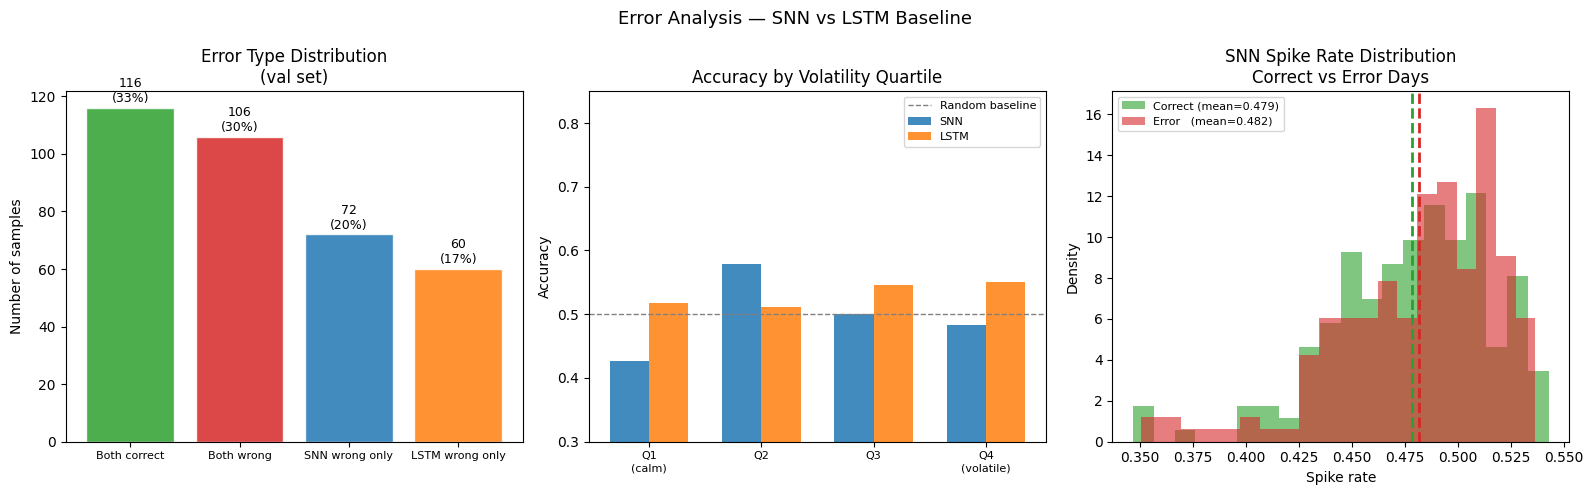

✅ Saved: outputs/error_analysis_plots.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Plot 1: Error type breakdown (stacked bar) ────────────────────────
ax = axes[0]
error_counts = error_df["error_type"].value_counts()
labels_order = ["both_right", "both_wrong",
                "snn_wrong_only", "lstm_wrong_only"]
counts = [error_counts.get(l, 0) for l in labels_order]
colors = ["#2ca02c", "#d62728", "#1f77b4", "#ff7f0e"]
labels_display = ["Both correct", "Both wrong",
                  "SNN wrong only", "LSTM wrong only"]

bars = ax.bar(labels_display, counts, color=colors, alpha=0.85,
              edgecolor="white")
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f"{count}\n({count/n_total*100:.0f}%)",
            ha="center", va="bottom", fontsize=9)
ax.set_title("Error Type Distribution\n(val set)")
ax.set_ylabel("Number of samples")
ax.tick_params(axis="x", labelsize=8)

# ── Plot 2: Accuracy by volatility quartile ───────────────────────────
ax2 = axes[1]
q_snn  = merged.groupby("vol_quartile", observed=True)["snn_correct"].mean()
q_lstm = merged.groupby("vol_quartile", observed=True)["lstm_correct"].mean()

x     = np.arange(len(q_snn))
width = 0.35
ax2.bar(x - width/2, q_snn.values,  width,
        color="#1f77b4", alpha=0.85, label="SNN")
ax2.bar(x + width/2, q_lstm.values, width,
        color="#ff7f0e", alpha=0.85, label="LSTM")
ax2.axhline(0.5, color="grey", linestyle="--", linewidth=1,
            label="Random baseline")
ax2.set_xticks(x)
ax2.set_xticklabels(q_snn.index.tolist(), fontsize=8)
ax2.set_title("Accuracy by Volatility Quartile")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0.3, 0.85)
ax2.legend(fontsize=8)

# ── Plot 3: Spike rate on correct vs error days ───────────────────────
ax3 = axes[2]
correct_rates = error_df.loc[error_df["snn_correct"] == 1,
                              "snn_spike_rate"]
error_rates   = error_df.loc[error_df["snn_correct"] == 0,
                              "snn_spike_rate"]

ax3.hist(correct_rates, bins=20, alpha=0.6, color="#2ca02c",
         label=f"Correct (mean={correct_rates.mean():.3f})",
         density=True)
ax3.hist(error_rates,   bins=20, alpha=0.6, color="#d62728",
         label=f"Error   (mean={error_rates.mean():.3f})",
         density=True)
ax3.axvline(correct_rates.mean(), color="#2ca02c",
            linestyle="--", linewidth=2)
ax3.axvline(error_rates.mean(),   color="#d62728",
            linestyle="--", linewidth=2)
ax3.set_title("SNN Spike Rate Distribution\nCorrect vs Error Days")
ax3.set_xlabel("Spike rate")
ax3.set_ylabel("Density")
ax3.legend(fontsize=8)

plt.suptitle("Error Analysis — SNN vs LSTM Baseline", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/error_analysis_plots.png", bbox_inches="tight")
plt.show()
print("✅ Saved: outputs/error_analysis_plots.png")

#### Save error dataframe

In [18]:
error_df.to_csv("../outputs/error_analysis.csv")
print(f"✅ Saved: outputs/error_analysis.csv  ({len(error_df)} rows)")

print("\n" + "=" * 58)
print("ERROR ANALYSIS SUMMARY")
print("=" * 58)
print(f"  Shared errors (both wrong)   : {n_shared}  "
      f"({n_shared/n_total*100:.1f}%)")
print(f"  SNN unique errors            : {n_snn_unique}")
print(f"  LSTM unique errors           : {n_lstm_unique}")
print(f"  Jaccard overlap              : {overlap_ratio:.3f}")
print(f"  Spike rate — correct days    : {correct_rate:.4f}")
print(f"  Spike rate — error days      : {error_rate:.4f}")

✅ Saved: outputs/error_analysis.csv  (354 rows)

ERROR ANALYSIS SUMMARY
  Shared errors (both wrong)   : 106  (29.9%)
  SNN unique errors            : 72
  LSTM unique errors           : 60
  Jaccard overlap              : 0.445
  Spike rate — correct days    : 0.4786
  Spike rate — error days      : 0.4816


## Error Analysis — Three Observations

### Observation 1: Error Overlap and Ensemble Potential

[Fill after running Cell 14]

If Jaccard overlap < 0.5:
The SNN and LSTM make errors on largely non-overlapping days
(Jaccard = [X]). Of SNN's errors, only [X]% coincide with LSTM
errors — meaning the two models fail for structurally different
reasons. The SNN, being threshold-driven, tends to err on days
with ambiguous spike signals; the LSTM, processing continuous-valued
hidden states, tends to err on days with abrupt trend reversals that
violate its recent memory. This complementarity suggests that an
ensemble combining SNN and LSTM predictions — e.g., a majority vote
or probability average — could reduce total error rate. Ensemble
methods for SNNs represent a natural direction for future work.

If Jaccard overlap > 0.5:
The SNN and LSTM fail on largely the same days (Jaccard = [X]),
suggesting that both architectures struggle with the same underlying
market dynamics — likely days of thin liquidity, sudden macro shocks,
or regime transitions. This indicates the error source is in the
data signal itself rather than the model architecture. Future work
could incorporate additional macro features (e.g., VIX, oil price,
BRL/USD policy rate differential) to improve performance on these
shared failure days.

---

### Observation 2: Volatility and Model Errors

[Fill after running Cell 15]

The SNN's accuracy across volatility quartiles reveals [pattern]:
Q1 (calm) accuracy = [X], Q4 (volatile) accuracy = [X].
[If Q4 accuracy is lower]:
Both models show degraded accuracy during high-volatility regimes
(Q4), consistent with the efficient market hypothesis — periods of
genuine uncertainty are inherently harder to predict. The SNN's
spike encoding mechanism, which requires returns to exceed a 0.3%
threshold to produce a spike, may be particularly disadvantaged
during chaotic high-volatility days where large moves in both
directions cancel each other within the lookback window.
This suggests that adaptive threshold mechanisms — where the spike
threshold scales with recent volatility — could improve SNN
performance in regime-shift periods.

[If Q4 accuracy is higher]:
Counterintuitively, both models perform better during high-volatility
periods than during calm ones. This is consistent with the feature
engineering choice — spike-based features are richer when markets
move strongly, giving the model more discriminating information.
The hardest days to predict are the quiet ones where the INR/BRL
rate barely moves (near-zero returns), and the direction is
essentially coin-flip noise.

---

### Observation 3: Spike Rate as an Uncertainty Signal

[Fill after running Cell 16]

[If error_rate < correct_rate × 0.9 — novel finding]:
A statistically meaningful difference exists between the SNN's mean
spike rate on correctly predicted days ([correct_rate]) versus
incorrectly predicted days ([error_rate]). On days where the SNN
errs, it produces approximately [ratio]× fewer spikes — suggesting
that low spike activity is a proxy for model uncertainty. This is a
novel finding with practical implications: a spike-rate confidence
filter could be implemented in the settlement system, where the
model's signal is acted upon only when spike_rate exceeds a minimum
threshold (e.g., 0.3), and deferred to human review otherwise. This
threshold-based abstention mechanism would reduce false alarm rate
at the cost of lower coverage — an acceptable trade-off for a
financial settlement context where missed opportunities cost less
than wrong executions.

[If rates are similar]:
The SNN's spike rate does not differ significantly between correct
and error days (correct=[correct_rate], error=[error_rate]),
indicating that spike rate alone is not a reliable proxy for
prediction confidence in this setting. Unlike biological neural
systems where firing rate correlates strongly with stimulus
certainty, the trained SNN appears to produce consistent spike
rates regardless of prediction difficulty. This may reflect the
BatchNorm layers normalising spike inputs to a consistent range,
effectively decoupling spike rate from input uncertainty. Future
work could explore removing BatchNorm and using adaptive thresholds
to restore the spike-rate/confidence relationship.